# Bollywood Movies Data Analysis and Visualization

**Author:** Rohit Nema  

This project performs exploratory data analysis (EDA) and data visualization on a Bollywood movies dataset to identify trends in ratings, genres, release years, etc using Python data analysis libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
bollywood=pd.read_csv('bollywood.csv', index_col=0)
df=pd.DataFrame(bollywood)
df.head(10)

,Release Date,MovieName,ReleaseTime,Genre,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
SlNo,,,,,,,,,
1,18-Apr-14,2 States,LW,Romance,36,104.00,8576361,26622,2527
2,04-Jan-13,Table No. 21,N,Thriller,10,12.00,1087320,1129,137
3,18-Jul-14,Amit Sahni Ki List,N,Comedy,10,4.00,572336,586,54
4,04-Jan-13,Rajdhani Express,N,Drama,7,0.35,42626,86,19
5,04-Jul-14,Bobby Jasoos,N,Comedy,18,10.80,3113427,4512,1224
6,30-May-14,Citylights,HS,Drama,7,35.00,1076591,1806,84
7,19-Sep-14,Daawat-E-Ishq,N,Comedy,30,24.60,3905050,8315,1373
8,11-Jan-13,Matru Ki Bijlee Ka Mandola,N,Comedy,33,40.00,2435283,4326,647
9,10-Jan-14,Dedh Ishqiya,LW,Comedy,31,27.00,2333067,2436,591


In [3]:
# Data Exploration
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 1 to 149
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Release Date         149 non-null    object 
 1   MovieName            149 non-null    object 
 2   ReleaseTime          149 non-null    object 
 3   Genre                149 non-null    object 
 4   Budget               149 non-null    int64  
 5   BoxOfficeCollection  149 non-null    float64
 6   YoutubeViews         149 non-null    int64  
 7   YoutubeLikes         149 non-null    int64  
 8   YoutubeDislikes      149 non-null    int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 11.6+ KB


**The dataset has 10 columns(including S.No) and 149 entries.** <br>
**Column datatypes include object, int64 and float64.**<br>
**There are no null values in any columns of the dataset.**<br>

In [5]:
df.duplicated().sum()

np.int64(0)

**No duplicated rows in dataset**

In [4]:
df.describe()

,Budget,BoxOfficeCollection,YoutubeViews,YoutubeLikes,YoutubeDislikes
count,149.000000,149.000000,1.490000e+02,149.000000,149.000000
mean,29.442953,55.667248,3.337920e+06,7877.536913,1207.818792
std,28.237981,94.494531,3.504407e+06,12748.047191,1852.692938
min,2.000000,0.010000,4.354000e+03,1.000000,1.000000
25%,11.000000,8.780000,1.076591e+06,1377.000000,189.000000
50%,21.000000,28.000000,2.375050e+06,4111.000000,614.000000
75%,35.000000,57.450000,4.550051e+06,9100.000000,1419.000000
max,150.000000,735.000000,2.317107e+07,101275.000000,11888.000000


**Some important observations -** <br>
1. Highest Budget- 150 crore <br>
2. Highest BoxOfficeCollection - 735 crore <br>
3. Highest Trailer views on Youtube - 23171067 <br>

4. Average BoxOfficeCollection - 55.67 crore

In [7]:
# Data Cleaning

In [8]:
total_missing_values = df.isnull().sum().sum()
print(f"Total missing values in the DataFrame: {total_missing_values}") 

Total missing values in the DataFrame: 0


**There are no missing values in the dataset.**

In [7]:
anomalies = df[(df['YoutubeLikes'] == 1) & (df['YoutubeDislikes'] == 1)]
print(f"Number of rows with exactly 1 like and 1 dislike: {len(anomalies)}")

df = df[~((df['YoutubeLikes'] == 1) & (df['YoutubeDislikes'] == 1))]

df.reset_index(drop=True, inplace=True)
df.index+=1
print(df)

Number of rows with exactly 1 like and 1 dislike: 4
    Release Date                    MovieName ReleaseTime      Genre  Budget  \
1      18-Apr-14                     2 States          LW    Romance      36   
2      04-Jan-13                 Table No. 21           N  Thriller       10   
3      18-Jul-14           Amit Sahni Ki List           N     Comedy      10   
4      04-Jan-13             Rajdhani Express           N     Drama        7   
5      04-Jul-14                 Bobby Jasoos           N     Comedy      18   
..           ...                          ...         ...        ...     ...   
141    27-Feb-15           Dum Laga Ke Haisha           N     Comedy      15   
142    13-Mar-15                         NH10           N   Thriller      13   
143    20-Mar-15  Dilliwali Zaalim Girlfriend           N     Comedy      32   
144    20-Mar-15                     Hunterrr           N     Comedy       5   
145    23-May-14                Kochadaiiyaan          HS     Action

**It is highly unlikely that a trailer having views in thousands and even higher can have just one like and dislike. <br>
Therefore, 4 such rows have been dropped.**

In [8]:
# Stripping whitespace
df['Genre'] = df['Genre'].str.strip()

In [ ]:
# Visualization

C:\Users\nitin\AppData\Local\Temp\ipykernel_11212\3940308102.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(movies_genre, palette='plasma')


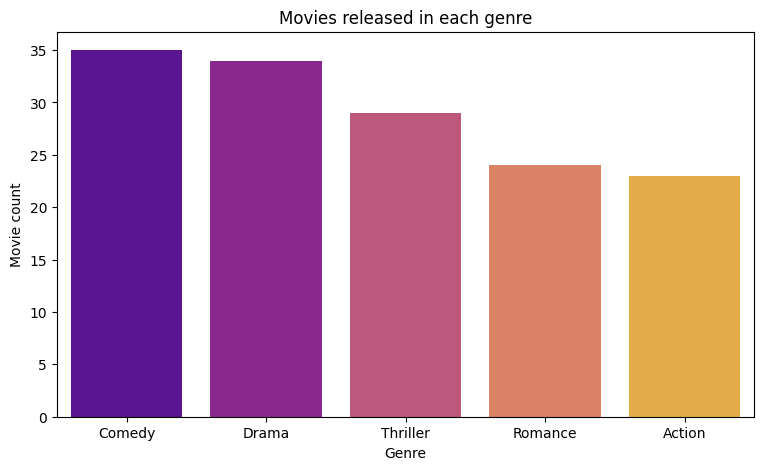

In [10]:
# 1. Movies and genres
# Movies released in each genre
movies_genre=df['Genre'].value_counts()
plt.figure(figsize=(9,5))
sns.barplot(movies_genre, palette='plasma')
plt.title("Movies released in each genre")
plt.xlabel("Genre")
plt.ylabel("Movie count")
plt.show()

**From the above barplot, we can say that the Comedy genre had the highest number of film releases.**

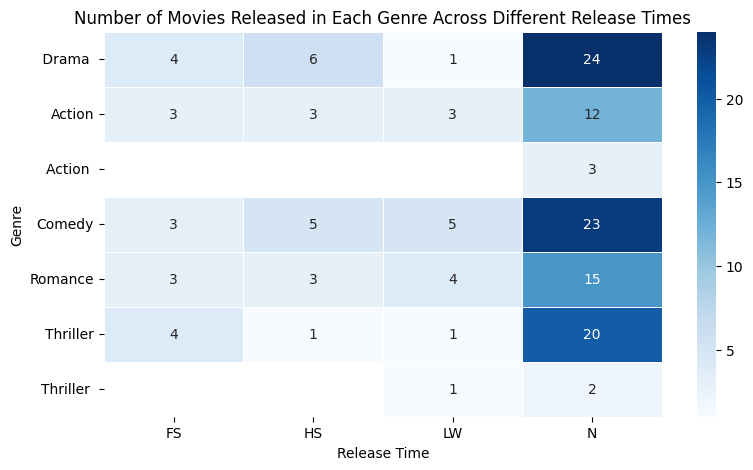

In [10]:
# Movies in each genre that got released in different release times
genre_release_count = df.groupby(['Genre', 'ReleaseTime']).size().reset_index(name='Movie Count')
pivot_table = genre_release_count.pivot(index='Genre', columns='ReleaseTime', values='Movie Count')
plt.figure(figsize=(9, 5))
sns.heatmap(pivot_table, cmap="Blues", annot=True, fmt='g', linewidths=0.5)
plt.title("Number of Movies Released in Each Genre Across Different Release Times")
plt.xlabel("Release Time")
plt.ylabel("Genre")
plt.show()

**Darker shades indicate higher movie counts.**

C:\Users\nitin\AppData\Local\Temp\ipykernel_11212\394082532.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')
C:\Users\nitin\AppData\Local\Temp\ipykernel_11212\394082532.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, palette="viridis")


Month with the most movie releases:
January with 19 releases


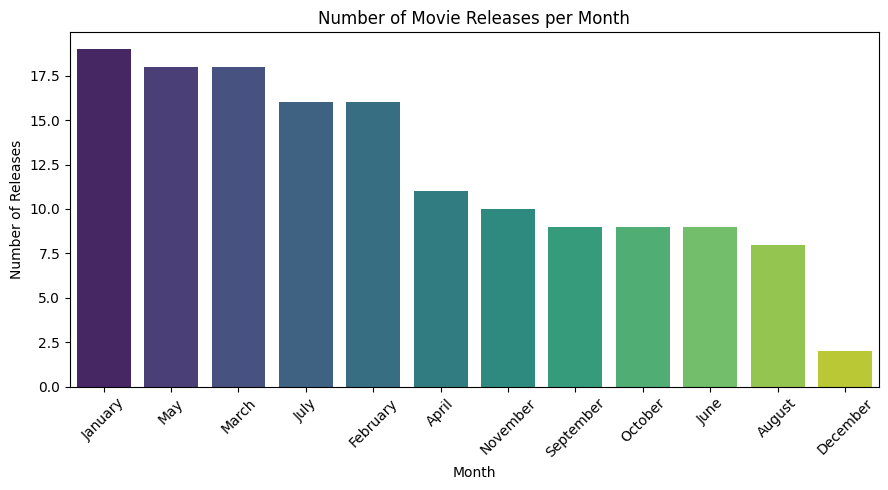

In [13]:
# 2.Box Office
# Month of the year that had maximum number of movie releases

df['Release Date'] = pd.to_datetime(df['Release Date'], errors='coerce')

df['Month'] = df['Release Date'].dt.month_name()

month_counts = df['Month'].value_counts()

print("Month with the most movie releases:")
print(month_counts.idxmax(), "with", month_counts.max(), "releases")

plt.figure(figsize=(9,5))
sns.barplot(x=month_counts.index, y=month_counts.values, palette="viridis")
plt.xticks(rotation=45)
plt.title("Number of Movie Releases per Month")
plt.xlabel("Month")
plt.ylabel("Number of Releases")
plt.tight_layout()
plt.show()


**It is evident from the plot that the first half of the year had much higher releases than the later half.**

C:\Users\nitin\AppData\Local\Temp\ipykernel_11212\2969794832.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  high_budget_df['Month'] = high_budget_df['Release Date'].dt.month_name()
C:\Users\nitin\AppData\Local\Temp\ipykernel_11212\2969794832.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=month_counts.index, y=month_counts.values, palette='magma')


Month with the most high-budget movie releases:
February with 9 releases


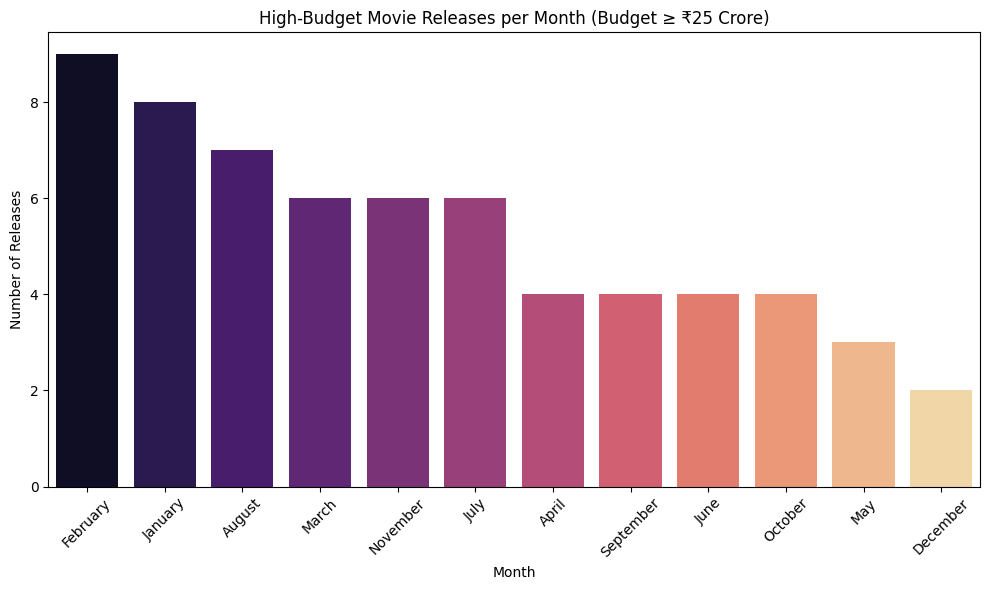

In [14]:
# Month of the year that sees most releases of high-budgeted movies, that is, movies with a budget of 25 crore or more? 

high_budget_df = df[df['Budget'] >= 25]

high_budget_df['Month'] = high_budget_df['Release Date'].dt.month_name()

month_counts = high_budget_df['Month'].value_counts()

print("Month with the most high-budget movie releases:")
print(month_counts.idxmax(), "with", month_counts.max(), "releases")

plt.figure(figsize=(10,6))
sns.barplot(x=month_counts.index, y=month_counts.values, palette='magma')
plt.xticks(rotation=45)
plt.title('High-Budget Movie Releases per Month (Budget ≥ ₹25 Crore)')
plt.xlabel('Month')
plt.ylabel('Number of Releases')
plt.tight_layout()
plt.show()

Top 10 Movies with Maximum ROI:
                     MovieName  Budget  BoxOfficeCollection       ROI
62                  Aashiqui 2      12                110.0  8.166667
87                          PK      85                735.0  7.647059
129                Grand Masti      35                298.0  7.514286
132               The Lunchbox      10                 85.0  7.500000
85                      Fukrey       5                 36.2  6.240000
56                    Mary Kom      15                104.0  5.933333
126                     Shahid       6                 40.0  5.666667
37   Humpty Sharma Ki Dulhania      20                130.0  5.500000
99          Bhaag Milkha Bhaag      30                164.0  4.466667
113            Chennai Express      75                395.0  4.266667


C:\Users\nitin\AppData\Local\Temp\ipykernel_11212\1626452510.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_roi, x='ROI', y='MovieName', palette='mako')


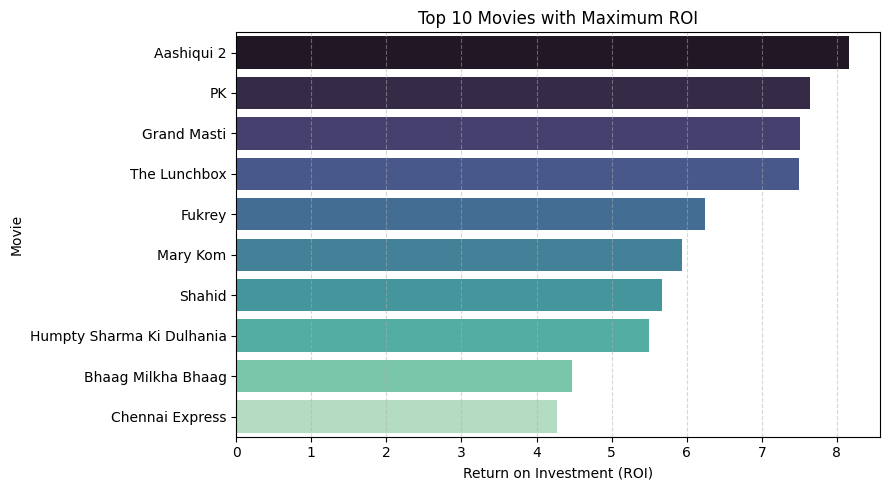

In [15]:
# Top 10 movies with the highest Return on Investment (ROI)
df['ROI'] = (df['BoxOfficeCollection'] - df['Budget']) / df['Budget']

top_10_roi = df.sort_values(by='ROI', ascending=False).head(10)

print("Top 10 Movies with Maximum ROI:")
print(top_10_roi[['MovieName', 'Budget', 'BoxOfficeCollection', 'ROI']])

plt.figure(figsize=(9, 5))
sns.barplot(data=top_10_roi, x='ROI', y='MovieName', palette='mako')
plt.title('Top 10 Movies with Maximum ROI')
plt.xlabel('Return on Investment (ROI)')
plt.ylabel('Movie')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

  ReleaseTime       ROI
0          LW  1.122006
1          FS  0.973853
2          HS  0.909781
3           N  0.671231


C:\Users\nitin\AppData\Local\Temp\ipykernel_23420\1692354244.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=roi_by_release_time, y='ROI', x='ReleaseTime', palette='flare')


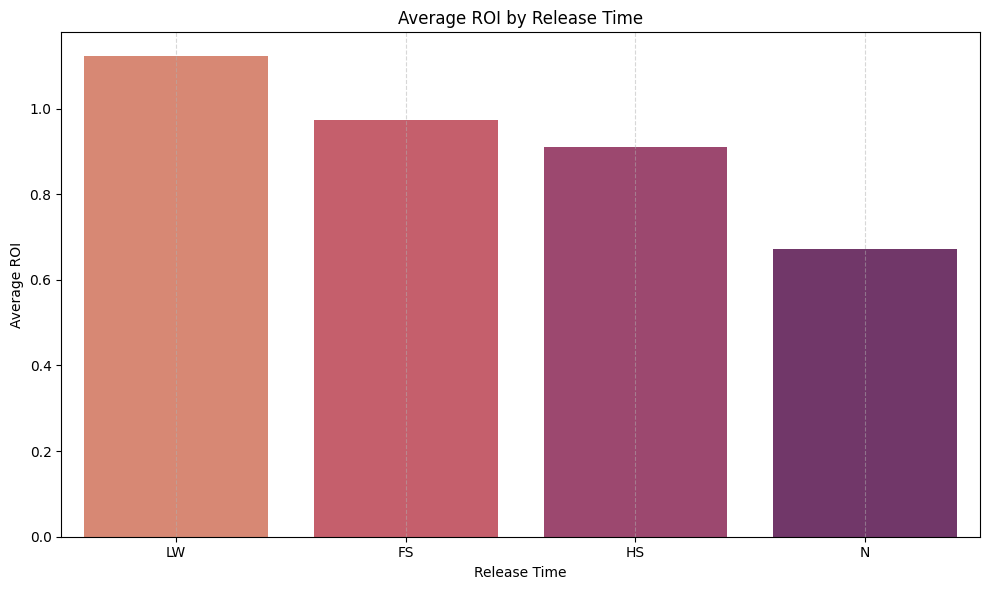

In [64]:
# Do movies have higher ROI if released on festive seasons or long weekends? Calculate the average ROI for different release times.

roi_by_release_time = df.groupby('ReleaseTime')['ROI'].mean().sort_values(ascending=False).reset_index()
print(roi_by_release_time)

plt.figure(figsize=(10, 6))
sns.barplot(data=roi_by_release_time, y='ROI', x='ReleaseTime', palette='flare')
plt.title('Average ROI by Release Time')
plt.ylabel('Average ROI')
plt.xlabel('Release Time')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Longweekend releases had a greater ROI as compared to other Release Times.**

In [16]:
#3. Social Media
# Correlation between BoxOfficeCollection and YoutubeLikes

correlation = df['BoxOfficeCollection'].corr(df['YoutubeLikes'])
print(f"Correlation between Box Office Collection and YouTube Likes: {correlation:.2f}")

if correlation > 0:
    print("The correlation is positive.")
elif correlation < 0:
    print("The correlation is negative.")
else:
    print("There is no correlation.")

Correlation between Box Office Collection and YouTube Likes: 0.69
The correlation is positive.


C:\Users\nitin\AppData\Local\Temp\ipykernel_11212\2036886959.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Genre', y='YoutubeLikes', palette='inferno')


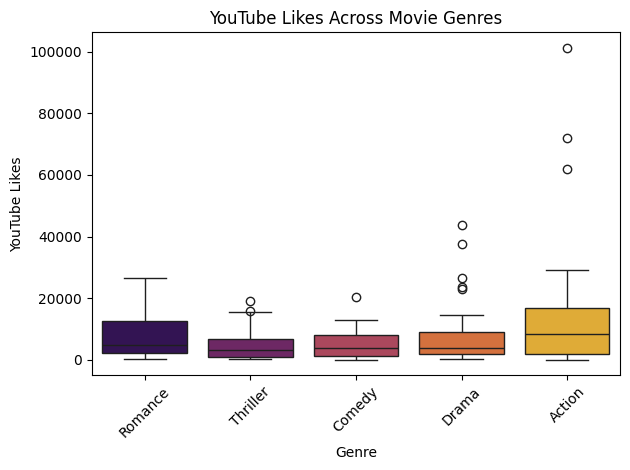

In [17]:
# Which genre of movies typically sees more YouTube likes?

sns.boxplot(data=df, x='Genre', y='YoutubeLikes', palette='inferno')
plt.title('YouTube Likes Across Movie Genres')
plt.xlabel('Genre')
plt.ylabel('YouTube Likes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Action Movies Receive the Highest Engagement Overall**<br>
**Some genres have strong outliers indicating viral hits.**

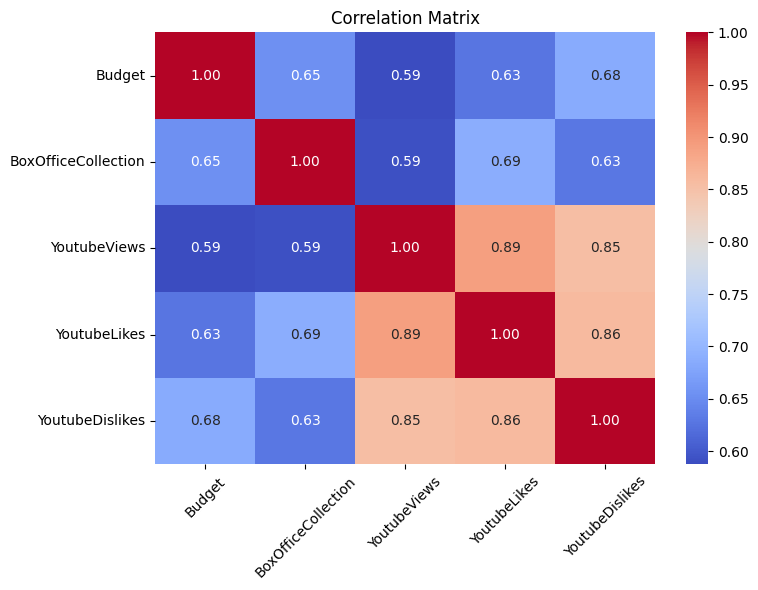

In [18]:
# Correlation Matrix for Budget, BoxOfficeCollection, YoutubeView, YoutubeLikes, YoutubeDislikes

correlation_data = df[['Budget', 'BoxOfficeCollection', 'YoutubeViews', 'YoutubeLikes', 'YoutubeDislikes']]

correlation_matrix = correlation_data.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Strong Positive Correlation between Box Office Collection and Budget**<br>
**YouTube Views and Likes are Highly Correlated**